In [43]:
library(deSolve)
library(ggplot2)
library(tidyr)

In [44]:
sizr_model <- function(time, state, parameters) {
  with(as.list(c(state, parameters)), {

    dS <- -beta * S * Z
    dI <-  beta * S * Z - (gamma + gamma_R + alpha) * I
    dZ <-  gamma * I - delta * (S + I + R) * Z - mu * Z
    dR <-  gamma_R * I + mu * Z

    return(list(c(dS, dI, dZ, dR)))
  })
}

params <- c(
  beta    = 1.0,
  gamma   = 4/5,
  gamma_R = 3/10,
  alpha   = 1/30,
  delta   = 1/10,
  mu      = 1 / (3 * 10^6)
)

initial_state <- c(
  S = 1.0,
  I = 0.0,
  Z = 0.1,  
  R = 0.0
)

times <- seq(0, 200, by = 0.01)

In [45]:
solution <- ode(y = initial_state, times = times, func = sizr_model, parms = params)

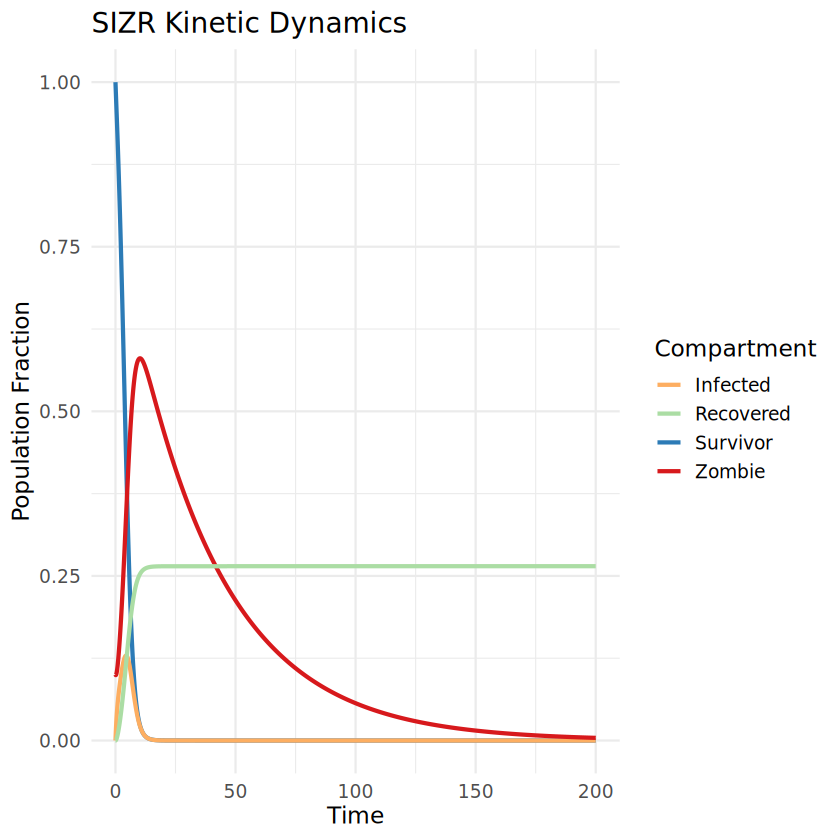

In [46]:
solution_df <- as.data.frame(solution)

ggplot(solution_df, aes(x = time)) +
  geom_line(aes(y = S, color = "Survivor"), linewidth = 1.2) +
  geom_line(aes(y = I, color = "Infected"), linewidth = 1.2) +
  geom_line(aes(y = Z, color = "Zombie"), linewidth = 1.2) +
  geom_line(aes(y = R, color = "Recovered"), linewidth = 1.2) +
  
  # Manually map the colors and create the legend
  scale_color_manual(name = "Compartment",
                     values = c("Survivor" = "#2c7bb6",
                                "Infected" = "#fdae61",
                                "Zombie" = "#d7191c",
                                "Recovered" = "#abdda4")) +
  labs(title = "SIZR Kinetic Dynamics",
       x = "Time",
       y = "Population Fraction") +
  theme_minimal(base_size = 14)